In [1]:
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np
import os
import scipy
import pickle

from neurolib.models.aln import ALNModel
from neurolib.models.rate_control import RateModel
import neurolib.utils.functions as func
from neurolib.utils import costFunctions as cost
from neurolib.utils import plotFunctions as plotFunc

plt.rcParams['image.cmap'] = 'plasma'
cpalette = sns.color_palette('plasma')
np.set_printoptions(precision=4)

font = {
    'family' : 'sans',
    'weight' : 'normal',
    'size'   : 14
       }

matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=16) 
matplotlib.rc('ytick', labelsize=16) 
matplotlib.rc('grid', c='0.5', ls='-', lw=0.5)  # solid gray grid lines
matplotlib.rc('savefig', dpi=300)       # higher res outputs
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

path = os.getcwd()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
def step_control(maxI_ = 1.):
    control_ = aln.getZeroControl()
    for i_time in range(control_.shape[2]):
        if ( float(i_time/control_.shape[2]) < 0.1):
            control_[:,:2,i_time] = - maxI_
        elif ( float(i_time/control_.shape[2]) > 0.5 and float(i_time/control_.shape[2]) < 0.6 ):
            control_[:,:2,i_time] = maxI_
    return control_

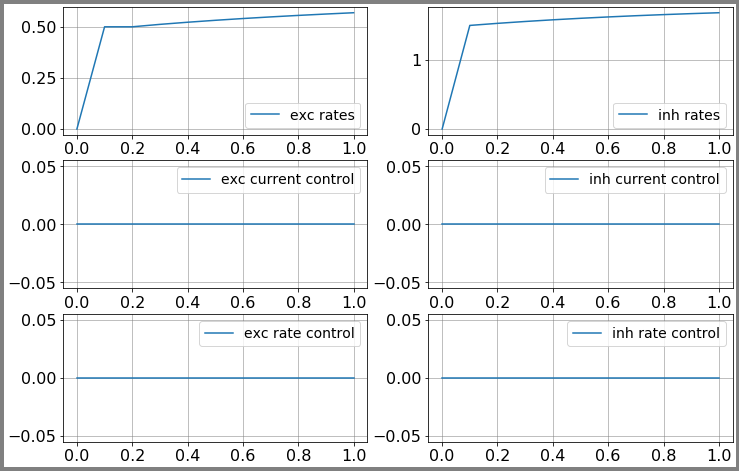

[[0.         0.         0.         0.00012    0.00035934 0.00072021
  0.00120445 0.00181363 0.00254915 0.00341219 0.00440382]]


In [19]:
aln = RateModel()

aln.params.dt = 0.1
aln.params['duration'] = 1.
control0 = aln.getZeroControl()
target = aln.getZeroTarget()
#control0 = step_control(maxI_ = 1.)

# NO ADAPTATION => else no bistability
aln.params.IA_init = np.array([0.])
aln.params.a = 0.
aln.params.b = 0.

# no noise
aln.params.sigma_ou = 0.
aln.params.mue_ext_mean = 0.
aln.params.sigmae_ext = 0.5
aln.params.ext_exc_current = 0.

#aln.params.c_gl = 1.
#aln.params.Ke_gl = 1.
#aln.params.tau_se = 1.
#aln.params.Jee_max = 1.
#aln.params.C = 1.
#aln.params.gL = 1.
#aln.params.cee = 1.
#aln.params.Ke = 1.

# no delay
aln.params.signalV = 0.
aln.params.de = 0.
aln.params.di = 0.

state = aln.getZeroFullState()
plotFunc.plot_traces(aln, control0)

output = aln.output_vars

state_vars = aln.state_vars
init_vars = aln.init_vars

for i in range(len(state_vars)):
    state[:,i,:] = aln.state[state_vars[i]]

high_state_vars = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    if aln.state[state_vars[i]].size == 1:
        high_state_vars[i] = aln.state[state_vars[i]][0]
    else:
        high_state_vars[i] = aln.state[state_vars[i]][0,-2]
        
high_state_vars[5] = 0.
high_state_vars[0] = 0.


print(aln.state["mufe"])

In [4]:
def setinitvars(vars):
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                if aln.params[init_vars[iv]].ndim == 2:
                    aln.params[init_vars[iv]][0,:] = vars[sv]
                else:
                    aln.params[init_vars[iv]][0] = vars[sv]
                    

In [5]:
tol = 1e-32

c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

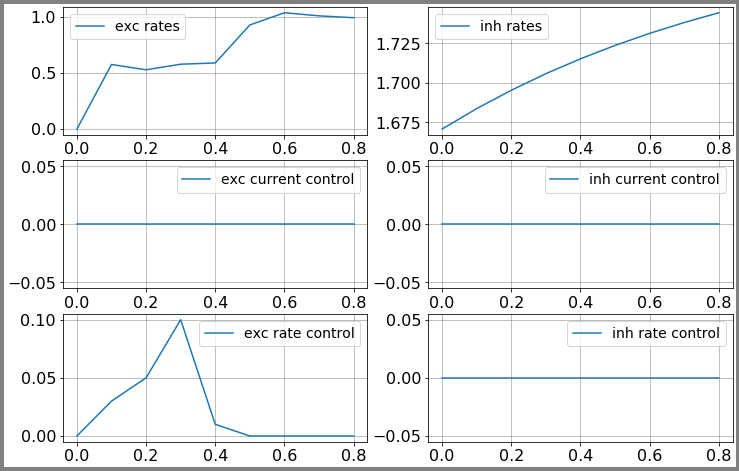

[[0.         0.         0.00982715 0.02557443 0.0560771  0.05925863
  0.05982327 0.06048616 0.06111927]]
[[0.00357215 0.00321494 0.01443286 0.02797893 0.04552516 0.04187373
  0.03796714 0.03455803 0.0315416 ]]
[[0.57157902 0.52418659 0.57397884 0.58263425 0.91458225 1.01037739
  0.96817644 0.93717178 0.90823423]]


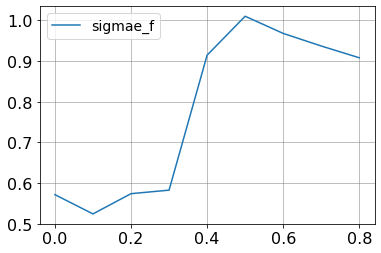

In [27]:
dur = 0.8
dur_pre = 0.
dur_post = 0.
aln.params.duration = dur

control_ind = 2
control0 = aln.getZeroControl()
#control0[0,control_ind,:] =  np.sin(np.arange(0,dur+1, 1))
#control0[0,control_ind,0] = 1.
#control0[0,control_ind,0] =  0.08
control0[0,control_ind,1] =  0.03
control0[0,control_ind,2] =  0.05
control0[0,control_ind,3] = 0.1
control0[0,control_ind,4] = 0.01
#control0[0,control_ind,:] = [0.08044293, 0.07931774, 0.05732154, 0.00748632, 0.07283936, 0.00502723, 0.00554333, 0.04001615]

setinitvars(high_state_vars)

plotFunc.plot_traces(aln, control0)

#print(aln.state["rates_exc"])
# 0.28603878 0.75 3.20786163

target = aln.getZeroTarget()
target[0,0,:] = aln.rates_exc[0,:]
target[0,1,:] = aln.rates_inh[0,:]

#plt.plot(aln.t, aln.state["seem"][0,:], label="seem")
#plt.plot(aln.t, aln.state["seev"][0,:], label="seev")
plt.plot(aln.t, aln.state["sigmae_f"][0,:], label="sigmae_f")
plt.legend()
#print(aln.state["rates_exc"])
#print(aln.state["mufe"])
print(aln.state["seem"])
print(aln.state["seev"])
print(aln.state["sigmae_f"])

In [28]:
cost.setParams(10., 1.0, 1.* 1e-3)
max_cntrl = 0.5
min_cntrl = 0.

setinitvars(high_state_vars)
max_it = 400
start_step = 1.
alg = "A1"
case = "test"

aln.params.duration = dur
control1 = aln.getZeroControl()
#control1[0,0,5] = 0.11
control2 = bestControlA
#control2 = bestControlA_A2[:,:,:]

# "HS", "FR", "PR", "HZ"
cgv = "HSl"

bestControlA, bestStateA, costA, runtimeA, grad = aln.A1(control1, target, c_scheme, u_mat, u_scheme,
        max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl, 
        min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post,
        CGVar = cgv, control_variables_ = [control_ind], prec_variables_ = [0,1])

print("grad = ", grad[0,control_ind,:])

print("best control = ", bestControlA[0,control_ind,:])

for i in range(1, len(costA)):
    if costA[i-1] < costA[i]:
        print("ERROR ---------------- in index ", i)
        
print("total runtime = ", runtimeA[-1])
# 0.0011694607062876605

set cost params
RUN  0 , total integrated cost =  0.33306937786534585
No valid variant of conjugate gradient descent selected, use none instead.
RUN  1 , total integrated cost =  0.046227448754851484
RUN  2 , total integrated cost =  0.012049525218409586
RUN  3 , total integrated cost =  0.00673394418532857
RUN  4 , total integrated cost =  0.0031038715651178976
RUN  5 , total integrated cost =  0.0018019636432533978
RUN  6 , total integrated cost =  0.0016866377773912078
RUN  7 , total integrated cost =  0.0013674154905005365
RUN  8 , total integrated cost =  0.0013097238127701264
RUN  9 , total integrated cost =  0.0012861994898883417
RUN  10 , total integrated cost =  0.0011381581975998345
RUN  11 , total integrated cost =  0.0009943542556237407
RUN  12 , total integrated cost =  0.0009830870129532215
RUN  13 , total integrated cost =  0.0009781852734740567
RUN  14 , total integrated cost =  0.0009710070696737507
RUN  15 , total integrated cost =  0.0009086012057067572
RUN  16 , tot

RUN  154 , total integrated cost =  0.0007037401463363398
RUN  155 , total integrated cost =  0.000703740073503857
RUN  156 , total integrated cost =  0.0007037400517767814
RUN  157 , total integrated cost =  0.0007037400335836661
RUN  158 , total integrated cost =  0.0007037400220705048
RUN  159 , total integrated cost =  0.0007037400113582657
RUN  160 , total integrated cost =  0.0007037399974792428
RUN  161 , total integrated cost =  0.0007037399840673622
RUN  162 , total integrated cost =  0.0007037399552468984
RUN  163 , total integrated cost =  0.000703739934067962
RUN  164 , total integrated cost =  0.0007037399277333283
RUN  165 , total integrated cost =  0.0007037399224463391
RUN  166 , total integrated cost =  0.0007037399190897796
RUN  167 , total integrated cost =  0.000703739915976255
RUN  168 , total integrated cost =  0.0007037399119275196
RUN  169 , total integrated cost =  0.0007037399080312318
RUN  170 , total integrated cost =  0.000703739905856694
RUN  171 , total i

RUN  307 , total integrated cost =  0.0007037398768042429
RUN  308 , total integrated cost =  0.0007037398768041727
RUN  309 , total integrated cost =  0.000703739876804116
RUN  310 , total integrated cost =  0.0007037398768040809
RUN  311 , total integrated cost =  0.000703739876804052
RUN  312 , total integrated cost =  0.000703739876804019
RUN  313 , total integrated cost =  0.0007037398768039986
RUN  314 , total integrated cost =  0.0007037398768039669
RUN  315 , total integrated cost =  0.0007037398768039475
RUN  316 , total integrated cost =  0.0007037398768039444
RUN  317 , total integrated cost =  0.000703739876803941
RUN  318 , total integrated cost =  0.0007037398768039337
RUN  319 , total integrated cost =  0.0007037398768039282
RUN  320 , total integrated cost =  0.0007037398768039258
RUN  321 , total integrated cost =  0.0007037398768039238
RUN  322 , total integrated cost =  0.0007037398768039222
RUN  323 , total integrated cost =  0.0007037398768039203
RUN  324 , total i

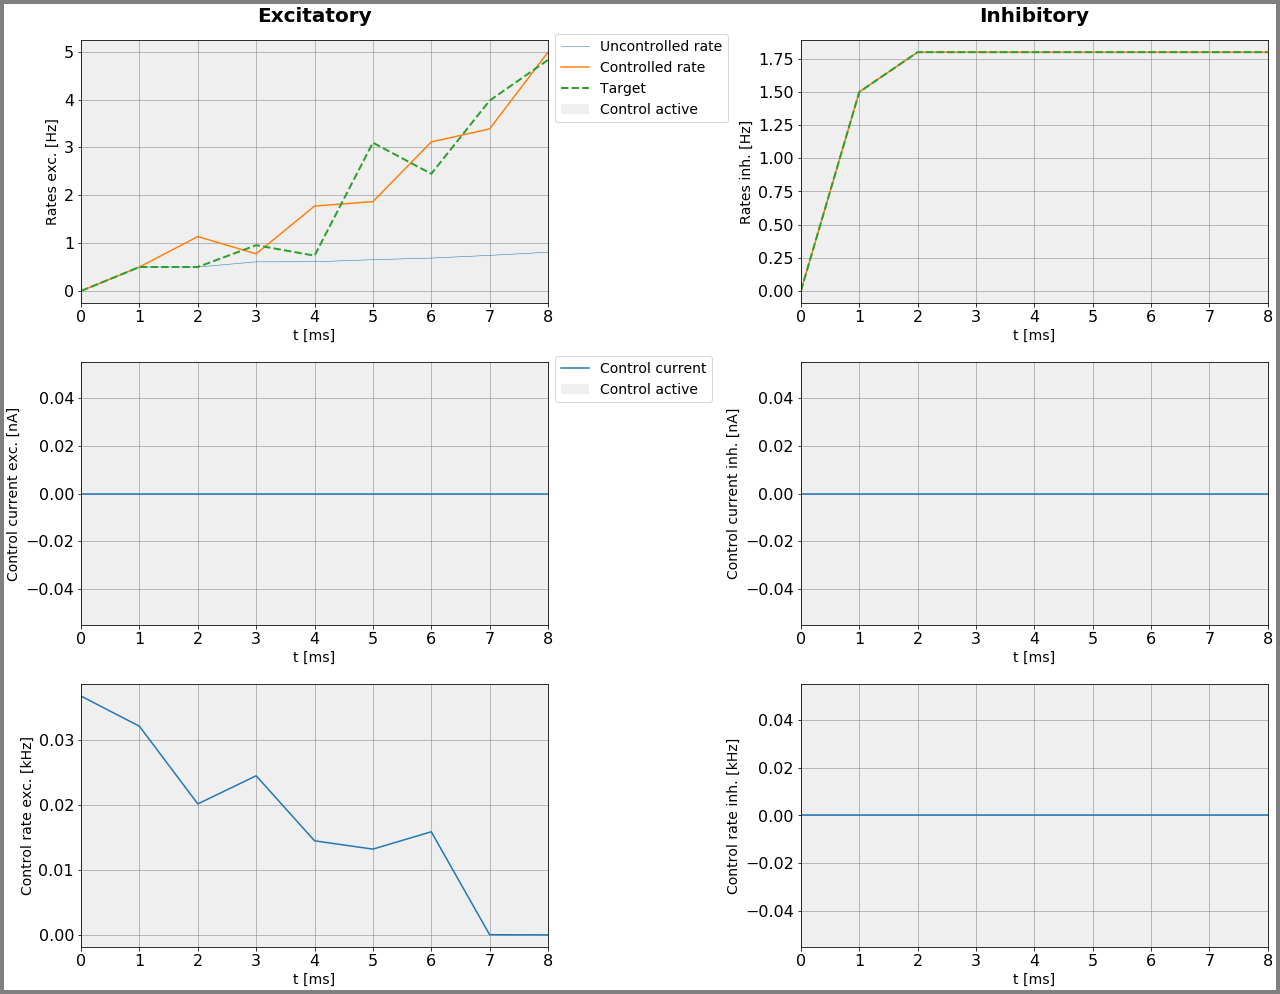

In [17]:
plotFunc.plot_control(aln, bestControlA, dur, dur_pre, dur_post, high_state_vars, target, path)

ValueError: x and y must have same first dimension, but have shapes (71,) and (8,)

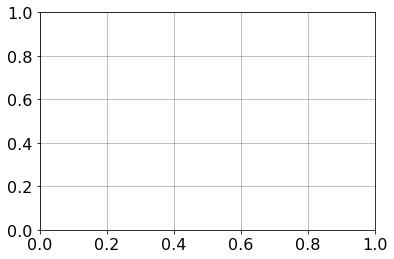

In [445]:
diff = control0 - bestControlA
#diff[0,2,-2:] = 0.

t = np.arange(0,dur+0.1, 0.1)

plt.plot(t, diff[0,0,:], label="difference in exc current control")
plt.plot(t, diff[0,1,:], label="difference in inh current control")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()
plt.show()

plt.plot(t, diff[0,2,:], label="difference in exc rate control")
plt.plot(t, diff[0,3,:], label="difference in inh rate control")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()
plt.show()

In [12]:
setinitvars(high_state_vars)
max_it = 100
start_step = 1.
alg = "A2"
case = "test"
incl_step = 10
test_step = 1e-8

aln.params.duration = dur
control3 = aln.getZeroControl()
#control4 = bestControlA_A2[:,:,:]

bestControlA_A2, bestStateA_A2, costA_A2, runtimeA_A2 = aln.A2(control3, target,
        max_iteration_ = max_it,  tolerance_ = tol, include_timestep_ = incl_step,
        start_step_ = start_step, test_step_ = test_step, max_control_ = max_cntrl,
        min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre,
        t_sim_post_ = dur_post, control_variables_ = [control_ind])

RUN  0 , total integrated cost:  9.506807258866564
RUN  1 , total integrated cost:  1.0539433939565523
RUN  2 , total integrated cost:  0.7868275646389654
RUN  3 , total integrated cost:  0.50952238156377
RUN  4 , total integrated cost:  0.3155369032060668
RUN  5 , total integrated cost:  0.1530387697008041
RUN  6 , total integrated cost:  0.08392808262128232
RUN  7 , total integrated cost:  0.05393435768003763
RUN  8 , total integrated cost:  0.03997553478576933
RUN  9 , total integrated cost:  0.02963450718991941
RUN  10 , total integrated cost:  0.023103958766195698
RUN  11 , total integrated cost:  0.020021789037952015
RUN  12 , total integrated cost:  0.018435563781620895
RUN  13 , total integrated cost:  0.017538255709811608
RUN  14 , total integrated cost:  0.016949907217008262
RUN  15 , total integrated cost:  0.016483124416504027
RUN  16 , total integrated cost:  0.01610220204847894
RUN  17 , total integrated cost:  0.01576038828404639
RUN  18 , total integrated cost:  0.01543

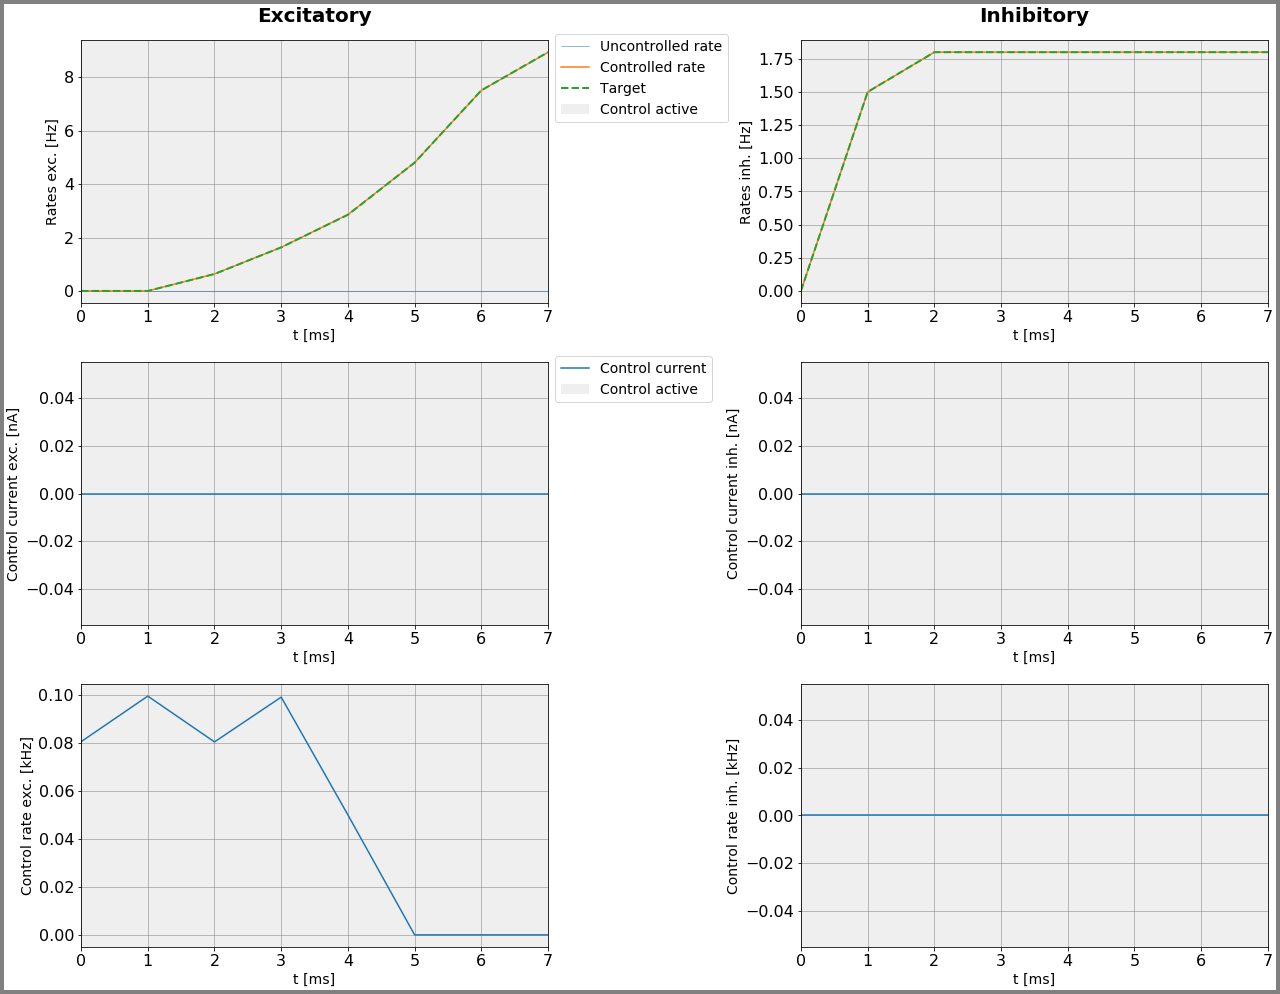

In [816]:
plotFunc.plot_control(aln, bestControlA_A2, dur, dur_pre, dur_post, high_state_vars, target, path)

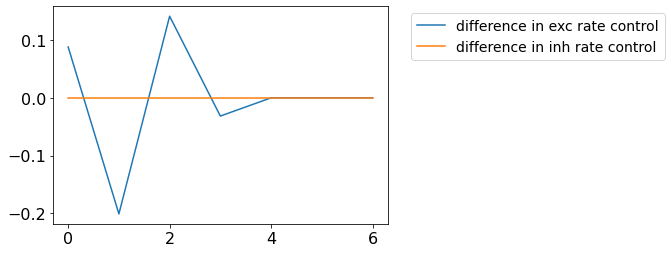

In [227]:
diff = control0 - bestControlA_A2
diff[0,2,-2:] = 0.

t = np.arange(0,dur+aln.params.dt, aln.params.dt)

plt.plot(t, diff[0,2,:], label="difference in exc rate control")
plt.plot(t, diff[0,3,:], label="difference in inh rate control")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()
plt.show()

-0.0004884455958080736


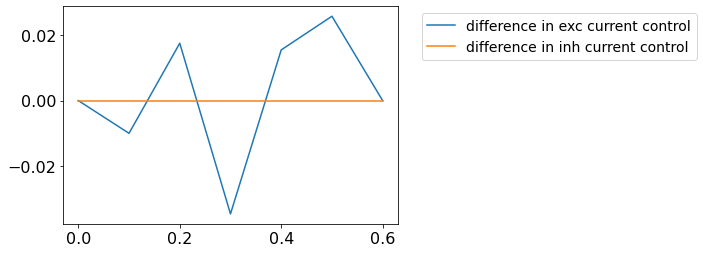

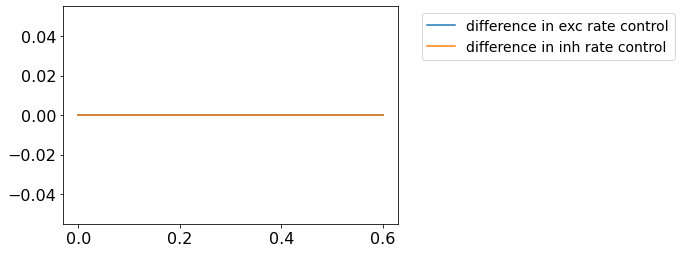

In [29]:
diff = bestControlA - bestControlA_A2
#diff[0,2,-2:] = 0.

c_diff = costA_A2[6] - costA[3]
print(c_diff)

t = np.arange(0,dur+0.1, 0.1)

plt.plot(t, diff[0,0,:], label="difference in exc current control")
plt.plot(t, diff[0,1,:], label="difference in inh current control")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()
plt.show()

plt.plot(t, diff[0,2,:], label="difference in exc rate control")
plt.plot(t, diff[0,3,:], label="difference in inh rate control")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()
plt.show()

In [748]:
np.sqrt(0.)

0.0